### My Question
What was the typical danceability score for the most streamed Spotify songs in 2023, and how are danceability scores distributed?

### My Study
This is an **observational study**.

- **Why it is an observational study:**
  The researchers observed and recorded existing attributes (such as danceability %, BPM, energy %, and streams) of songs that were already released and streamed on Spotify in 2023. The data was collected purely by observation without manipulating, altering, or intervening in how the music was created, produced, or consumed.
- **Why it is not an experiment:**
  In a true experiment, researchers deliberately impose a treatment or manipulate independent variables across randomized treatment and control groups to evaluate cause-and-effect. In this dataset, nobody assigned artists or songs to different musical conditions or controlled listening groups; all audio features and stream counts were pre-existing and naturally occurring.
- **Why it is not a census:**
  A census collects data from **every single individual in the entire population**. If the population is defined as all music tracks released or available on Spotify (which comprises more than 100 million songs), this dataset of **953 songs** represents only a subset/sample—specifically the most-streamed tracks of 2023. Because it does not measure every song in the population, it is not a census study.

### My Analysis

--- Five-Number Summary ---
   Statistic Danceability %
     Minimum          23.0%
    Q1 (25%)          57.0%
Median (50%)          69.0%
    Q3 (75%)          78.0%
     Maximum          96.0%

--- Measures of Center & Spread ---
                Statistic          Value
          Sample Size (n)      953 songs
                     Mean         66.97%
                   Median          69.0%
                     Mode 70% (43 songs)
       Standard Deviation         14.63%
Interquartile Range (IQR)          21.0%


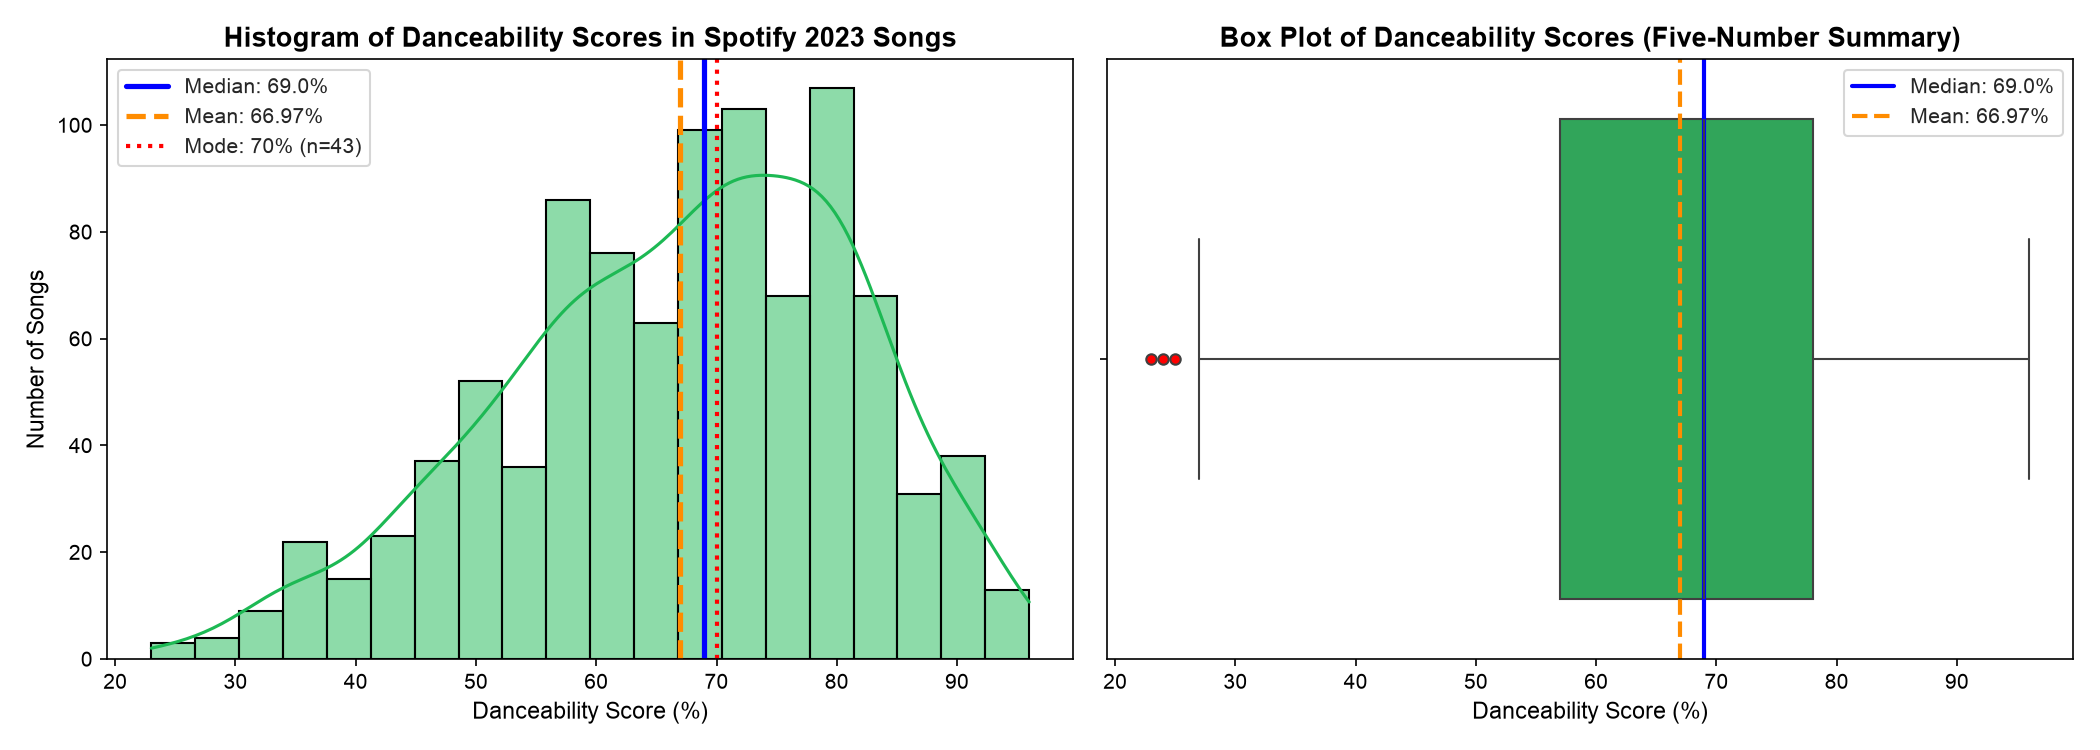

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling
sns.set_theme(style="whitegrid")

# 1. Load the Spotify 2023 dataset
df = pd.read_csv('spotify-2023.csv', encoding='cp1252')
danceability = df['danceability_%']

# 2. Compute Measures of Central Tendency & Five-Number Summary
mean_val = danceability.mean()
std_val = danceability.std()
median_val = danceability.median()
q1_val = danceability.quantile(0.25)
q3_val = danceability.quantile(0.75)
iqr_val = q3_val - q1_val
min_val = danceability.min()
max_val = danceability.max()
mode_val = danceability.mode()[0]
mode_count = danceability.value_counts().loc[mode_val]

# Display Five-Number Summary Table
five_num_summary = pd.DataFrame({
    'Statistic': ['Minimum', 'Q1 (25%)', 'Median (50%)', 'Q3 (75%)', 'Maximum'],
    'Danceability %': [
        f"{min_val:.1f}%",
        f"{q1_val:.1f}%",
        f"{median_val:.1f}%",
        f"{q3_val:.1f}%",
        f"{max_val:.1f}%"
    ]
})

print("--- Five-Number Summary ---")
print(five_num_summary.to_string(index=False))

# Display Measures of Central Tendency & Spread Table
summary_stats = pd.DataFrame({
    'Statistic': [
        'Sample Size (n)',
        'Mean',
        'Median',
        'Mode',
        'Standard Deviation',
        'Interquartile Range (IQR)'
    ],
    'Value': [
        f"{len(danceability)} songs",
        f"{mean_val:.2f}%",
        f"{median_val:.1f}%",
        f"{mode_val}% ({mode_count} songs)",
        f"{std_val:.2f}%",
        f"{iqr_val:.1f}%"
    ]
})

print("
--- Measures of Center & Spread ---")
print(summary_stats.to_string(index=False))

# 3. Visualizations: Histogram and Box Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Histogram with KDE and Measures of Center
sns.histplot(danceability, bins=20, color='#1DB954', edgecolor='black', kde=True, ax=axes[0])
axes[0].axvline(median_val, color='blue', linestyle='-', linewidth=2.5, label=f'Median: {median_val:.1f}%')
axes[0].axvline(mean_val, color='darkorange', linestyle='--', linewidth=2.5, label=f'Mean: {mean_val:.2f}%')
axes[0].axvline(mode_val, color='red', linestyle=':', linewidth=2, label=f'Mode: {mode_val}% (n={mode_count})')
axes[0].set_title('Histogram of Danceability Scores in Spotify 2023 Songs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Danceability Score (%)', fontsize=11)
axes[0].set_ylabel('Number of Songs', fontsize=11)
axes[0].legend(fontsize=10)

# (b) Box Plot representing Spread and Skewness
sns.boxplot(x=danceability, color='#1DB954', flierprops={'marker': 'o', 'markersize': 5, 'markerfacecolor': 'red'}, ax=axes[1])
axes[1].axvline(median_val, color='blue', linestyle='-', linewidth=2, label=f'Median: {median_val:.1f}%')
axes[1].axvline(mean_val, color='darkorange', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}%')
axes[1].set_title('Box Plot of Danceability Scores (Five-Number Summary)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Danceability Score (%)', fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()


### My Conclusion

1. **Answer & Key Statistics:**
- **Median (69.0%) vs. Mean (66.97%):**
  When describing the typical score of a **quantitative variable** like `danceability_%`, the **median** and **mean** are standard and statistically appropriate metrics:
  - **Median (69.0%):** Represents the exact center of the distribution, where 50% of songs score above 69.0% and 50% score below. Because the distribution is moderately left-skewed with a lower tail stretching down to 23.0%, the median is the most robust and resistant measure of central tendency against extreme lower values.
  - **Mean (66.97% ≈ 67.0%):** The arithmetic average is slightly lower than the median (66.97% vs. 69.0%), which directly reflects the negative skewness pulling the mean toward the low-end tail.
- **Why Mode (70%) is Not Typically Used for Quantitative Data:**
  While the discrete mode is **70%** (appearing 43 times), the mode is primarily intended for categorical or discrete nominal data. For quantitative continuous/percentage data, the mode can be arbitrary or unstable because it depends heavily on rounding precision or bin definitions. Describing the typical song solely with the mode overlooks the spread and quantitative nature of the data. However, the close convergence of the median (69.0%), mean (66.97%), and mode (70.0%) demonstrates that popular tracks in 2023 consistently favored high danceability.
- **Five-Number Summary & Spread:**
  - **Minimum:** 23.0%
  - **First Quartile (Q1):** 57.0%
  - **Median:** 69.0%
  - **Third Quartile (Q3):** 78.0%
  - **Maximum:** 96.0%
  - **Interquartile Range (IQR):** 21.0% (Q3 − Q1 = 78.0% − 57.0%), showing that the middle 50% of popular songs cluster tightly between 57.0% and 78.0%.
  - **Standard Deviation:** 14.63%

2. **Screenshot of Desmos Graph:**

![Desmos Histogram and Box Plot of Danceability](desmos_screenshot.png)
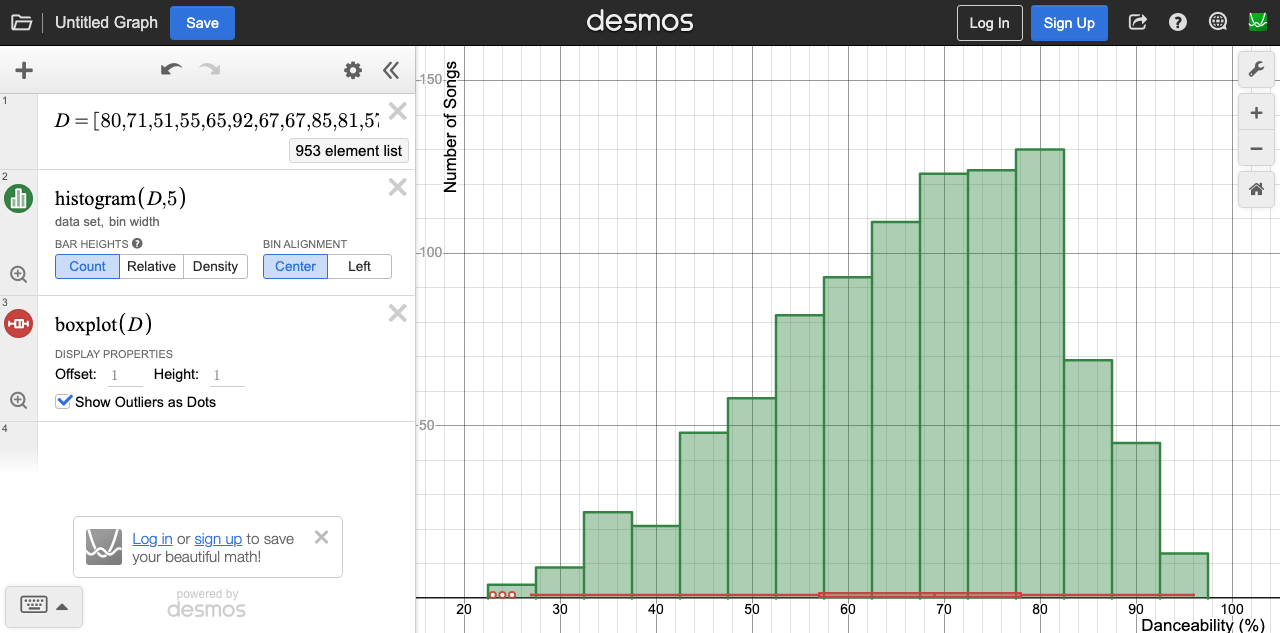

3. **Graph Interpretation:**
- **Distribution Shape:** The Desmos histogram and box plot demonstrate that the distribution of `danceability_%` is **unimodal** and **moderately left-skewed (negatively skewed)**. The highest concentration of songs lies between 65% and 80%, with a long trailing tail tapering down to the minimum of 23.0%.
- **Box Plot Interpretation:** The Desmos box plot confirms this negative skew: the median line (69.0%) is positioned closer to Q3 (78.0%) than to Q1 (57.0%). Furthermore, the lower whisker and individual low-end outlier dots (tracks at 23%, 24%, and 25%) extend substantially farther to the left than the upper whisker extends to the maximum (96.0%).
- **Summary:** The graphical evidence confirms why the median (69.0%) is the best single measure of central tendency for this skewed distribution, while showing that hit songs on Spotify in 2023 were overwhelmingly upbeat and danceable.